In [1]:
from nb_utils import set_root

PROJECT_ROOT = set_root(level = 2)

# IRT, Beta4, and Item Characteristic Curves

This notebook introduces a latent-ability view of evaluation.
The goal is to move from surface-level predictive performance to a description of how success changes as ability changes.

## Why introduce IRT here?

The previous notebook showed that some examples are consistently more ambiguous than others.
IRT gives us language and structure for that intuition:

- ability describes the subject, model, or learner;
- difficulty describes the item;
- discrimination describes how sharply an item separates low and high ability;
- guessing captures the idea that some success can happen even at low ability.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from utils.handson import make_item_bank, plot_beta4_family, plot_iccs

## Step 1: Create a simple item bank

We begin with three stylized items: easy, medium, and hard.
This is enough to explain the mechanics of ICCs without overwhelming the audience.

In [3]:
from utils.handson import sigmoid
theta = sigmoid(np.linspace(-4, 4, 3_00))

In [4]:
item_bank = make_item_bank(
        [
        {
            "item": "example_1",
            "difficulty": 0.2,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 2,
        },
        {
            "item": "example_2",
            "difficulty": 0.3,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 2,
        },
        {
            "item": "example_3",
            "difficulty": 0.5,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 2,
        },
        {
            "item": "example_3",
            "difficulty": 0.7,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 2,
        },
    ]
)
item_bank

,item,difficulty,discrimination_sign,discrimination_magnitude
0,example_1,0.2,0.5,2
1,example_2,0.3,0.5,2
2,example_3,0.5,0.5,2
3,example_3,0.7,0.5,2


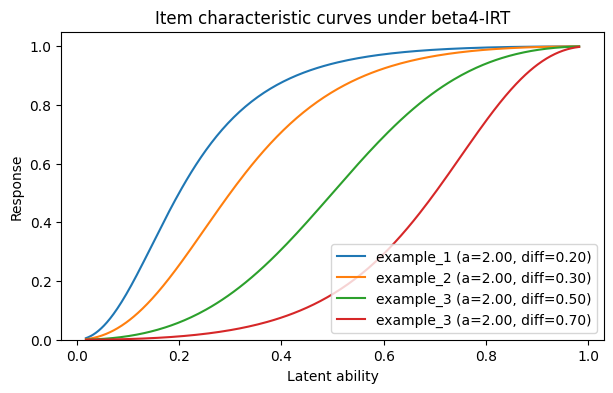

In [6]:
ax = plot_iccs(item_bank, theta=theta, discrimination=2)
plt.show()

In [ ]:
item_bank = make_item_bank(
    [
        {
            "item": "example_1",
            "difficulty": -1,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 2,
        },
        {
            "item": "example_2",
            "difficulty": 0,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 2,
        },
        {
            "item": "example_3",
            "difficulty": 1,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 2,
        },
    ]
)
ax = plot_iccs(item_bank, theta=theta)
plt.show()

## Reading the ICCs

Recommended points to explain on the figure:

- The curve moves to the right as difficulty increases.
- The slope gets steeper as discrimination increases.
- A non-zero lower bound reflects guessing.
- The y-axis is not a score; it is the probability of a correct response.

## Step 2: Connect IRT to supervised learning

For the workshop, a useful conceptual bridge is:

- a student in educational testing becomes a model in machine learning;
- an item becomes an example or benchmark case;
- correctness still means a successful response.

Under this interpretation, IRT-style curves tell us how likely a method is to succeed on items of different difficulty.

## Step 3: Why mention Beta4?

A logistic ICC is often enough for intuition, but sometimes we want extra flexibility in the curve shape.
That is where Beta4 becomes a useful talking point in this workshop.

The broad message is that Beta4-style response functions can model richer transitions between low and high probability regions.

In [ ]:
ax = plot_beta4_family(theta=theta)
plt.show()

## Recommended Beta4 narrative

This is a good script for the oral explanation:

1. Start from the familiar logistic response curve.
2. Explain that some applications need more flexible shapes.
3. Use the Beta4 family to discuss asymmetry and shape variation.
4. Emphasize that richer curves can reflect richer item behavior.

If you want to be mathematically precise in the final talk, replace the placeholder plot with the exact Beta4 formulation from your research notes.

## Suggested audience questions

- Which curve would correspond to an item that becomes informative only at high ability?
- Which curve would be considered less discriminative?
- Why might a flexible item-response shape matter when comparing supervised methods?

## Takeaways

1. IRT gives a language for separating ability from difficulty.
2. ICCs make the relationship between ability and success visible.
3. Beta4 is useful when a simple logistic curve is not expressive enough.
4. This sets up CLAIRE as a method for latent-ability-aware analysis in supervised settings.